In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Data Analyst Projects/05_Telecom_Customer_Churn_Analytics/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0.0)

print("TotalCharges Datatype:", df['TotalCharges'].dtype)

TotalCharges Datatype: float64


In [13]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

print(df['SeniorCitizen'].value_counts())

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


In [14]:
duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()

Total Duplicate Rows: 0


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   str    
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

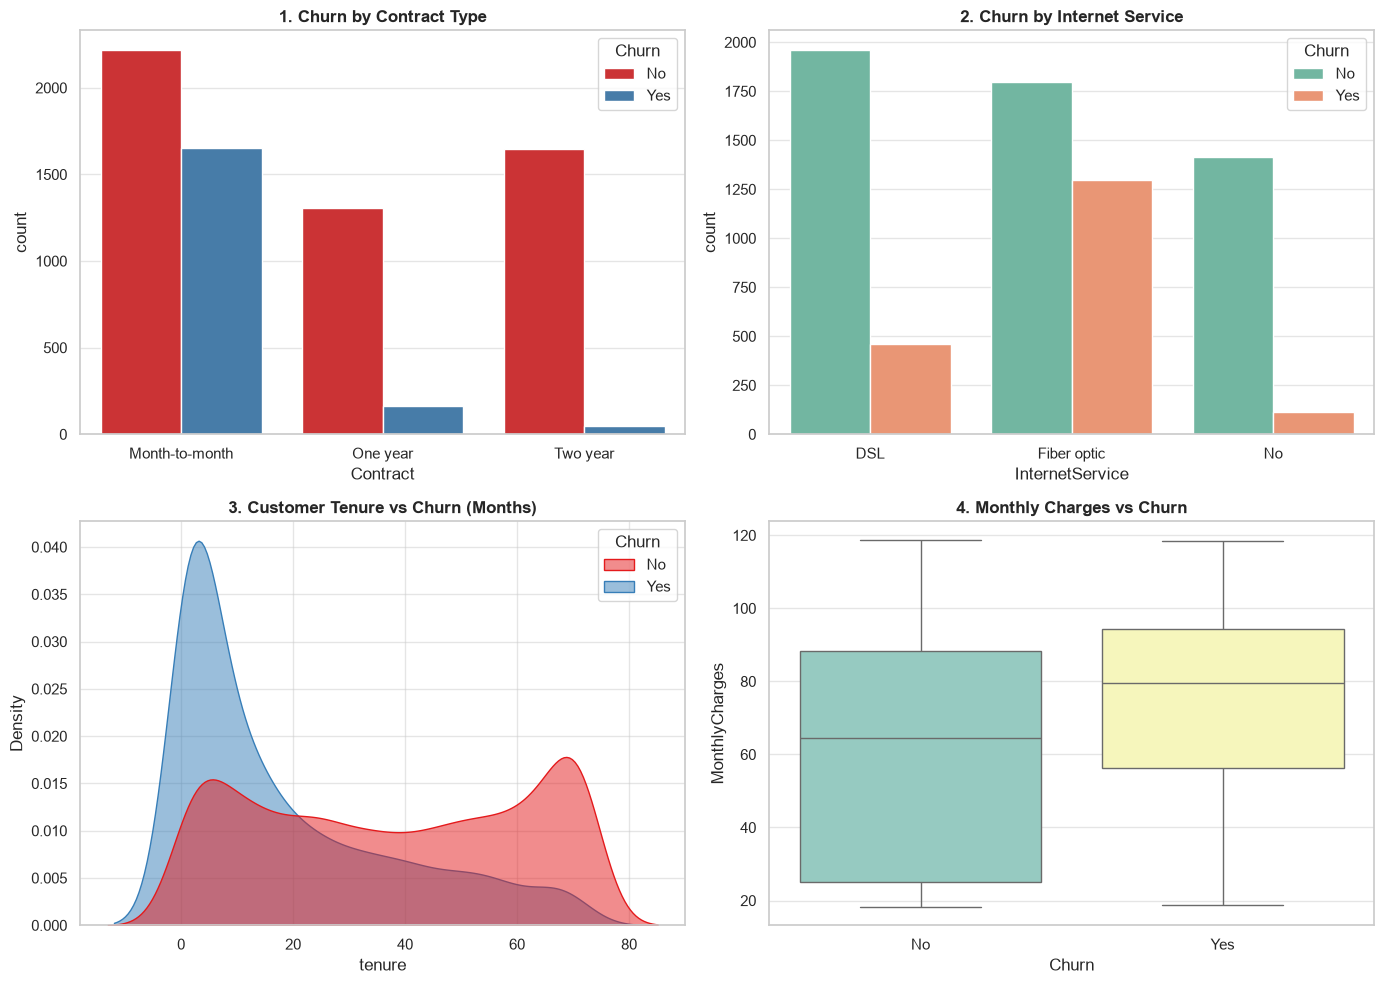

In [26]:
sns.set_theme(style="whitegrid")

# 2x2 Grid setup
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Churn by Contract Type
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0, 0], palette='Set1')
axes[0, 0].set_title('1. Churn by Contract Type', fontsize=12, fontweight='bold')

# Plot 2: Churn by Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('2. Churn by Internet Service', fontsize=12, fontweight='bold')

# Plot 3: Tenure vs Churn Distribution (Clear & Balanced visibility)
sns.kdeplot(data=df, x='tenure', hue='Churn', common_norm=False, ax=axes[1, 0], fill=True, alpha=0.5, palette='Set1')
axes[1, 0].set_title('3. Customer Tenure vs Churn (Months)', fontsize=12, fontweight='bold')

# Plot 4: Monthly Charges vs Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', ax=axes[1, 1], palette='Set3', legend=False)
axes[1, 1].set_title('4. Monthly Charges vs Churn', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

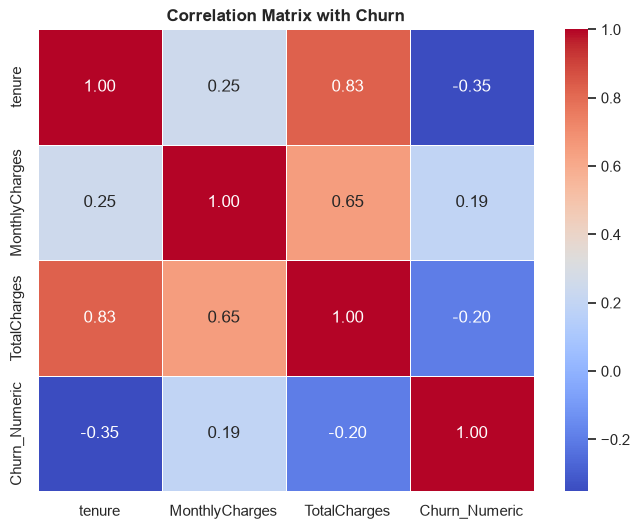

In [27]:
# Correlation Heatmap
df_temp = df.copy()
df_temp['Churn_Numeric'] = df_temp['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_temp[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Correlation Matrix with Churn', fontsize=12, fontweight='bold')
plt.show()

In [28]:
# Cleaned CSV Export
output_path = "C:/Data Analyst Projects/05_Telecom_Customer_Churn_Analytics/Telco_Customer_Churn_Cleaned.csv"
df.to_csv(output_path, index=False)

print("EDA completed & Cleaned dataset exported successfully!")

EDA completed & Cleaned dataset exported successfully!
